# Classifying accents using unbalanced dataset
### SETUP CODE FOR EXPERIMENT 1

In [ ]:
### TODO PLACE GTID HERE:
GTID = "PUT GTID HERE"

In [2]:
import os
base = "/home/hice1/"+GTID+"/scratch/cv-corpus-25.0-2026-03-09"
for f in os.listdir(base):
    print(f)

en


In [3]:
# Common Voice organizes by language; English is usually "en"
en_path = os.path.join(base, "en")
print(os.listdir(en_path))

['reported.tsv', 'invalidated.tsv', 'dev.tsv', 'test.tsv', 'unvalidated_sentences.tsv', 'clips', 'other.tsv', 'train.tsv', 'validated_sentences.tsv', 'clip_durations.tsv', 'README.md', 'validated.tsv']


In [4]:
import pandas as pd
tsv_path = os.path.join(en_path, "validated.tsv")
df = pd.read_csv(tsv_path, sep="\t")
print(df.shape)
print(df.columns.tolist())
df.head()

/tmp/ipykernel_1182869/2741631514.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tsv_path, sep="\t")


(1880682, 13)
['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']


,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,00095e762ba9e83fbffc38d3617aaeaa9bfd94d9f586c5...,common_voice_en_18127094.mp3,3343e59984bbb29777f68734d81dc9a9855b8c40d8b4ac...,"Yes, this is the right place.",NaN,2,0,NaN,NaN,NaN,NaN,en,NaN
1,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,common_voice_en_27710027.mp3,b2cf0b3308b6e00b46f3e48fe59682452ae737a596aa29...,"Joe Keaton disapproved of films, and Buster al...",NaN,3,1,NaN,NaN,NaN,NaN,en,NaN
2,0013037a1d45cc33460806cc3f8ecee9d536c45639ba4c...,common_voice_en_699711.mp3,de9d68400821d73ee6868687d0562c60282ee9446d1191...,She'll be all right.,NaN,2,1,NaN,NaN,NaN,NaN,en,NaN
3,0014c5a3e5715a54855257779b89c2bb498d470b225866...,common_voice_en_21953345.mp3,14c0567a0a6c4ea49f2a1b2ac73de940b8c07779c70bf0...,six,NaN,3,2,NaN,NaN,NaN,NaN,en,Benchmark
4,001519f234e04528a2b36158c205dbe61c8da45ab0242f...,common_voice_en_27340672.mp3,a975540ad0c7ceaaec94cd17ae3b55e1eaf89a61d4a579...,It is a busy market town that serves a large s...,NaN,2,0,NaN,NaN,NaN,NaN,en,NaN


In [5]:
#distribution of accent, age gender
for col in ["accents", "age", "gender"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))


--- accents ---
NaN                                                   843199
United States English                                 447120
England English                                       157679
India and South Asia (India, Pakistan, Sri Lanka)     110842
Canadian English                                       76997
Australian English                                     55498
Non native speaker|German English                      53295
Southern African (South Africa, Zimbabwe, Namibia)     26853
Scottish English                                       19390
New Zealand English                                    15198
Name: accents, dtype: int64

--- age ---
NaN          653901
twenties     457836
thirties     274950
fourties     174586
teens        111598
fifties      107192
sixties       83982
seventies     14535
eighties       1889
nineties        213
Name: age, dtype: int64

--- gender ---
male_masculine        879093
NaN                   691038
female_feminine       310341
do_no

Transcript: Yes, this is the right place.
Accent: nan
Age: nan
Gender: nan
Audio file: /home/hice1/mhasman3/scratch/cv-corpus-25.0-2026-03-09/en/clips/common_voice_en_18127094.mp3
Exists: True
Sample rate: 48000 Hz, Duration: 3.82s


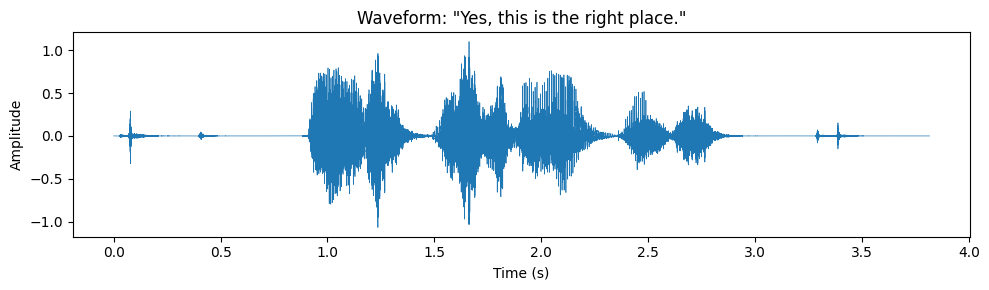

In [6]:
import soundfile as sf
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np

clips_dir = os.path.join(en_path, "clips")
row = df.iloc[0]

print("Transcript:", row["sentence"])
print("Accent:", row["accents"])
print("Age:", row["age"])
print("Gender:", row["gender"])
audio_path = os.path.join(clips_dir, row["path"])
print("Audio file:", audio_path)
print("Exists:", os.path.exists(audio_path))

# Load audio
y, sr = sf.read(audio_path)
print(f"Sample rate: {sr} Hz, Duration: {len(y)/sr:.2f}s")

# Play inline
ipd.display(ipd.Audio(y, rate=sr))

# Waveform plot
plt.figure(figsize=(10, 3))
plt.plot(np.linspace(0, len(y)/sr, len(y)), y, linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Waveform: \"{row['sentence'][:60]}\"")
plt.tight_layout()
plt.show()

In [7]:
# Load all on-disk filenames into a set first — one os.listdir() call instead of millions of exists() checks
on_disk_files = set(os.listdir(clips_dir))

df["on_disk"] = df["path"].apply(lambda p: os.path.basename(p) in on_disk_files)
df_local = df[df["on_disk"]].copy().reset_index(drop=True)
print(f"Clips available locally: {len(df_local)} / {len(df)}")

Clips available locally: 515945 / 1880682


### END OF SETUP

In [8]:
import os
import pandas as pd

base      = "/home/hice1/"+GTID+"/scratch/cv-corpus-25.0-2026-03-09"
en_path   = os.path.join(base, "en")
clips_dir = os.path.join(en_path, "clips")

# Load metadata
df = pd.read_csv(os.path.join(en_path, "validated.tsv"), sep="\t")

# Filter to on-disk clips only
on_disk_files = set(os.listdir(clips_dir))
df["on_disk"]   = df["path"].apply(lambda p: os.path.basename(p) in on_disk_files)
df["full_path"] = df["path"].apply(lambda p: os.path.join(clips_dir, p))
df_local = df[df["on_disk"]].copy().reset_index(drop=True)

print(f"Total in TSV:   {len(df):,}")
print(f"On disk:        {len(df_local):,}")
print()

# Accent counts — on disk only
print("=== On-disk clips per accent ===")
accent_counts = (
    df_local["accents"]
    .fillna("unlabeled")
    .value_counts()
)
print(accent_counts.to_string())

/tmp/ipykernel_1182869/2848336745.py:9: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(en_path, "validated.tsv"), sep="\t")


Total in TSV:   1,880,682
On disk:        515,945

=== On-disk clips per accent ===
unlabeled                                                                         246671
United States English                                                             137052
England English                                                                    49836
India and South Asia (India, Pakistan, Sri Lanka)                                  21414
Australian English                                                                 19645
Canadian English                                                                   15697
New Zealand English                                                                 7810
Scottish English                                                                    4950
Southern African (South Africa, Zimbabwe, Namibia)                                  3316
Irish English                                                                       3097
Filipino                  

In [9]:
import os
import pandas as pd
import numpy as np

base      = "/home/hice1/"+GTID+"/scratch/cv-corpus-25.0-2026-03-09"
en_path   = os.path.join(base, "en")
clips_dir = os.path.join(en_path, "clips")
out_dir   = "/home/hice1/"+GTID+"/scratch/accent_splits"
os.makedirs(out_dir, exist_ok=True)

# Reload
df = pd.read_csv(os.path.join(en_path, "validated.tsv"), sep="\t")
on_disk_files = set(os.listdir(clips_dir))
df["on_disk"]   = df["path"].apply(lambda p: os.path.basename(p) in on_disk_files)
df["full_path"] = df["path"].apply(lambda p: os.path.join(clips_dir, p))
df_local = df[df["on_disk"]].copy().reset_index(drop=True)
df_local["accent_raw"] = df_local["accents"].fillna("unlabeled")

# ── Accent → class mapping ──────────────────────────────────────────────────
ACCENT_MAP = {
    # Major classes
    "United States English":                                        "us",
    "United States English|Native speaker":                         "us",
    "United States English|western united states":                  "us",

    "England English":                                              "england",
    "England English|Northern England":                             "england",
    "England English|femalepublic school accent, quiet and under articualted finals": "rare",

    "India and South Asia (India, Pakistan, Sri Lanka)":            "india",
    "India and South Asia (India, Pakistan, Sri Lanka)|South India|Kannadiga": "india",

    "Australian English":                                           "australia",
    "Canadian English":                                             "canada",
    "New Zealand English":                                          "new_zealand",
    "Scottish English":                                             "scottish",
    "Southern African (South Africa, Zimbabwe, Namibia)":           "southern_african",
    "Irish English":                                                "irish",

    # Rare class
    "Filipino":                                                     "rare",
    "Singaporean English":                                          "rare",
    "Hong Kong English":                                            "rare",
    "Malaysian English":                                            "rare",
    "Welsh English":                                                "rare",
    "United States English|Transatlantic English":                  "rare",
    "England English|Academic southern English":                    "rare",
    "Non native speaker|German English":                            "rare",
    "West Indies and Bermuda (Bahamas, Bermuda, Jamaica, Trinidad)":"rare",
    "South Atlantic (Falkland Islands, Saint Helena)":              "rare",
    "french accent":                                                "rare",
    "Dutch English":                                                "rare",
    "Russian|Slavic":                                               "rare",
    "Austrian":                                                     "rare",
    "Northumbrian British English":                                 "rare",
    "Dutch":                                                        "rare",
    "New Jerseyan":                                                 "rare",
    "German|south-west German|South German accent|Alemannic German Accent": "rare",
}

# Apply mapping — unlabeled and anything not in map is dropped
df_local["accent"] = df_local["accent_raw"].map(ACCENT_MAP)
df_kept = df_local[df_local["accent"].notna()].copy().reset_index(drop=True)

print(f"Clips after accent filter: {len(df_kept):,}")
print()
print("=== Clips per class ===")
print(df_kept["accent"].value_counts().to_string())

# ── Test / train split ───────────────────────────────────────────────────────
# Fixed balanced test set: 200 per class
# Rare class has fewer clips so we use min(200, 20% of rare clips)
np.random.seed(42)

rare_total  = (df_kept["accent"] == "rare").sum()
test_rare   = min(200, int(rare_total * 0.20))
TEST_N      = {accent: 200 for accent in df_kept["accent"].unique()}
TEST_N["rare"] = test_rare

print(f"\nTest size for rare class: {test_rare}")

test_rows  = []
train_rows = []

for accent, group in df_kept.groupby("accent"):
    group  = group.sample(frac=1, random_state=42).reset_index(drop=True)
    n_test = TEST_N[accent]
    test_rows.append(group.iloc[:n_test])
    train_rows.append(group.iloc[n_test:])

df_test       = pd.concat(test_rows).reset_index(drop=True)
df_train_full = pd.concat(train_rows).reset_index(drop=True)

print(f"\nTest set:   {len(df_test):,} clips")
print(f"Train pool: {len(df_train_full):,} clips")
print()
print("=== Test counts per class ===")
print(df_test["accent"].value_counts().to_string())

# ── Proportional train sample ────────────────────────────────────────────────
TARGET_TRAIN_TOTAL = 25000

train_counts     = df_train_full["accent"].value_counts()
total_train_pool = train_counts.sum()

print(f"\n=== Proportional train sample (target {TARGET_TRAIN_TOTAL:,}) ===")
sampled_train = []

for accent, group in df_train_full.groupby("accent"):
    proportion = len(group) / total_train_pool
    n_sample   = max(1, round(proportion * TARGET_TRAIN_TOTAL))
    n_sample   = min(n_sample, len(group))
    sampled    = group.sample(n=n_sample, random_state=42)
    sampled_train.append(sampled)
    print(f"  {accent:<20} {proportion*100:5.1f}%  →  {n_sample:,} clips")

df_train = pd.concat(sampled_train).reset_index(drop=True)
print(f"\nFinal train set: {len(df_train):,} clips")

# ── Save ─────────────────────────────────────────────────────────────────────
df_train.to_csv(os.path.join(out_dir, "train.csv"), index=False)
df_test.to_csv(os.path.join(out_dir,  "test.csv"),  index=False)

# Label map — sorted for consistency
classes   = sorted(df_kept["accent"].unique())
label_map = {cls: i for i, cls in enumerate(classes)}
pd.DataFrame(
    list(label_map.items()), columns=["accent", "label_id"]
).to_csv(os.path.join(out_dir, "label_map.csv"), index=False)

print("\nLabel map:")
for k, v in label_map.items():
    print(f"  {v}  {k}")

print(f"\nSaved train.csv, test.csv, label_map.csv → {out_dir}")

/tmp/ipykernel_1182869/273728786.py:12: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(en_path, "validated.tsv"), sep="\t")


Clips after accent filter: 269,274

=== Clips per class ===
us                  137079
england              49862
india                21417
australia            19645
canada               15697
new_zealand           7810
rare                  6401
scottish              4950
southern_african      3316
irish                 3097

Test size for rare class: 200

Test set:   2,000 clips
Train pool: 267,274 clips

=== Test counts per class ===
australia           200
canada              200
england             200
india               200
irish               200
new_zealand         200
rare                200
scottish            200
southern_african    200
us                  200

=== Proportional train sample (target 25,000) ===
  australia              7.3%  →  1,819 clips
  canada                 5.8%  →  1,450 clips
  england               18.6%  →  4,645 clips
  india                  7.9%  →  1,985 clips
  irish                  1.1%  →  271 clips
  new_zealand            2.8%  →  712 

In [10]:
import sys
sys.path = [p for p in sys.path if ".local" not in p]
import torch
print(torch.__version__, torch.cuda.is_available())

2.1.0a0+32f93b1 True


In [11]:
### ONLY RUN CELL FIRST TIME RUNNING CODE: 

import os
import numpy as np
import soundfile as sf
import pandas as pd
from scipy.signal import stft
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

# ── Config ───────────────────────────────────────────────────────────────────
SPLITS_DIR  = "/home/hice1/"+GTID+"/scratch/accent_splits"
CACHE_DIR   = "/home/hice1/"+GTID+"/scratch/accent_spectrograms"
os.makedirs(CACHE_DIR, exist_ok=True)

SAMPLE_RATE  = 16000
CLIP_SECONDS = 3
CLIP_SAMPLES = SAMPLE_RATE * CLIP_SECONDS  # 48000 samples
N_FFT        = 512
HOP_LENGTH   = 160   # 10ms hop at 16kHz
N_MELS       = 64
TARGET_SHAPE = (N_MELS, 188)  # ~3 seconds of frames

# ── Mel filterbank (built once, reused per worker) ───────────────────────────
def make_mel_filterbank(sr=16000, n_fft=512, n_mels=64, fmin=0, fmax=8000):
    fft_freqs = np.linspace(0, sr / 2, n_fft // 2 + 1)
    mel_min   = 2595 * np.log10(1 + fmin / 700)
    mel_max   = 2595 * np.log10(1 + fmax / 700)
    mel_pts   = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_pts    = 700 * (10 ** (mel_pts / 2595) - 1)
    filters   = np.zeros((n_mels, n_fft // 2 + 1))
    for m in range(1, n_mels + 1):
        f_m_minus = hz_pts[m - 1]
        f_m       = hz_pts[m]
        f_m_plus  = hz_pts[m + 1]
        for k, freq in enumerate(fft_freqs):
            if f_m_minus <= freq <= f_m:
                filters[m - 1, k] = (freq - f_m_minus) / (f_m - f_m_minus)
            elif f_m <= freq <= f_m_plus:
                filters[m - 1, k] = (f_m_plus - freq) / (f_m_plus - f_m)
    return filters

MEL_FB = make_mel_filterbank()

def audio_to_melspec(path):
    """Load audio, trim/pad to 3s, compute log mel spectrogram."""
    try:
        audio, sr = sf.read(path, dtype="float32", always_2d=False)

        # Mix down to mono if stereo
        if audio.ndim == 2:
            audio = audio.mean(axis=1)

        # Resample crudely if needed (most CV clips are already 16kHz)
        if sr != SAMPLE_RATE:
            ratio  = SAMPLE_RATE / sr
            n_out  = int(len(audio) * ratio)
            audio  = np.interp(
                np.linspace(0, len(audio) - 1, n_out),
                np.arange(len(audio)),
                audio
            )

        # Trim or pad to exactly 3 seconds
        if len(audio) >= CLIP_SAMPLES:
            audio = audio[:CLIP_SAMPLES]
        else:
            audio = np.pad(audio, (0, CLIP_SAMPLES - len(audio)))

        # STFT
        _, _, Zxx = stft(audio, fs=SAMPLE_RATE, nperseg=N_FFT, noverlap=N_FFT - HOP_LENGTH)
        power = np.abs(Zxx) ** 2  # (n_fft//2+1, frames)

        # Mel filterbank
        mel = MEL_FB @ power  # (n_mels, frames)

        # Log mel
        mel = np.log(mel + 1e-9)

        # Trim or pad frames to TARGET_SHAPE
        if mel.shape[1] >= TARGET_SHAPE[1]:
            mel = mel[:, :TARGET_SHAPE[1]]
        else:
            mel = np.pad(mel, ((0, 0), (0, TARGET_SHAPE[1] - mel.shape[1])))

        return mel.astype(np.float32)

    except Exception:
        return None

def process_row(args):
    """Worker function: compute spectrogram and save to cache."""
    idx, full_path, out_path = args
    if os.path.exists(out_path):
        return (idx, "skip")
    mel = audio_to_melspec(full_path)
    if mel is None:
        return (idx, "error")
    np.save(out_path, mel)
    return (idx, "ok")

def cache_split(csv_path, split_name):
    df       = pd.read_csv(csv_path)
    n_errors = 0
    n_skip   = 0

    args_list = []
    for i, row in df.iterrows():
        fname    = os.path.splitext(os.path.basename(row["full_path"]))[0] + ".npy"
        out_path = os.path.join(CACHE_DIR, fname)
        args_list.append((i, row["full_path"], out_path))

    n_workers = min(8, cpu_count())
    print(f"\nCaching {split_name}: {len(args_list):,} clips using {n_workers} workers...")

    with Pool(n_workers) as pool:
        for idx, status in tqdm(
            pool.imap_unordered(process_row, args_list),
            total=len(args_list),
            desc=split_name,
            unit="clip"
        ):
            if status == "error":
                n_errors += 1
            elif status == "skip":
                n_skip += 1

    print(f"  Done. errors={n_errors}  skipped(already cached)={n_skip}")

# ── Run ───────────────────────────────────────────────────────────────────────
cache_split(os.path.join(SPLITS_DIR, "train.csv"), "train")
cache_split(os.path.join(SPLITS_DIR, "test.csv"),  "test")

print(f"\nAll spectrograms cached to {CACHE_DIR}")
print(f"Expected .npy shape per file: {TARGET_SHAPE}")


Caching train: 25,000 clips using 8 workers...


train: 100%|██████████| 25000/25000 [00:00<00:00, 31060.46clip/s]


  Done. errors=0  skipped(already cached)=25000

Caching test: 2,000 clips using 8 workers...


test: 100%|██████████| 2000/2000 [00:00<00:00, 32170.83clip/s]

  Done. errors=0  skipped(already cached)=2000

All spectrograms cached to /home/hice1/mhasman3/scratch/accent_spectrograms
Expected .npy shape per file: (64, 188)


In [12]:
import os

CACHE_DIR  = "/home/hice1/"+GTID+"/scratch/accent_spectrograms"
SPLITS_DIR = "/home/hice1/"+GTID+"/scratch/accent_splits"

# Count cached files
npy_files = [f for f in os.listdir(CACHE_DIR) if f.endswith(".npy")]
print(f"Cached spectrograms: {len(npy_files):,}")

# Verify splits still exist
for fname in ["train.csv", "test.csv", "label_map.csv"]:
    path = os.path.join(SPLITS_DIR, fname)
    exists = os.path.exists(path)
    print(f"  {fname}: {'OK' if exists else 'MISSING'}")

# Spot check one file loads correctly
import numpy as np
sample = np.load(os.path.join(CACHE_DIR, npy_files[0]))
print(f"\nSample spectrogram shape: {sample.shape}")  # expect (64, 188)
print(f"Sample dtype: {sample.dtype}")
print("\nAll good — skip block 3, proceed to block 4.")


Cached spectrograms: 48,509
  train.csv: OK
  test.csv: OK
  label_map.csv: OK

Sample spectrogram shape: (64, 188)
Sample dtype: float32

All good — skip block 3, proceed to block 4.


In [13]:
import os
import pandas as pd
import numpy as np

base      = "/home/hice1/"+GTID+"/scratch/cv-corpus-25.0-2026-03-09"
en_path   = os.path.join(base, "en")
clips_dir = os.path.join(en_path, "clips")

SPLITS_DIR = "/home/hice1/"+GTID+"/scratch/accent_splits"
CACHE_DIR  = "/home/hice1/"+GTID+"/scratch/accent_spectrograms"

# Verify everything is on disk
for fname in ["train.csv", "test.csv", "label_map.csv"]:
    path = os.path.join(SPLITS_DIR, fname)
    print(f"  {fname}: {'OK' if os.path.exists(path) else 'MISSING'}")

npy_files = [f for f in os.listdir(CACHE_DIR) if f.endswith(".npy")]
print(f"  Cached spectrograms: {len(npy_files):,}")

sample = np.load(os.path.join(CACHE_DIR, npy_files[0]))
print(f"  Sample shape: {sample.shape}")
print("\nAll good.")

  train.csv: OK
  test.csv: OK
  label_map.csv: OK
  Cached spectrograms: 48,509
  Sample shape: (64, 188)

All good.


In [14]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

BATCH_SIZE = 128

# ── Label map ────────────────────────────────────────────────────────────────
label_df  = pd.read_csv(os.path.join(SPLITS_DIR, "label_map.csv"))
LABEL_MAP = dict(zip(label_df["accent"], label_df["label_id"]))
NUM_CLASSES = len(LABEL_MAP)
print(f"Classes ({NUM_CLASSES}):")
for k, v in LABEL_MAP.items():
    print(f"  {v}  {k}")

# ── Dataset ──────────────────────────────────────────────────────────────────
class AccentDataset(Dataset):
    def __init__(self, csv_path, cache_dir, label_map, mean=None, std=None):
        self.df        = pd.read_csv(csv_path)
        self.cache_dir = cache_dir
        self.label_map = label_map
        self.mean      = mean
        self.std       = std

        pairs = []
        for _, row in self.df.iterrows():
            npy = os.path.join(cache_dir,
                  os.path.splitext(os.path.basename(row["full_path"]))[0] + ".npy")
            if os.path.exists(npy):
                pairs.append((npy, label_map[row["accent"]]))

        self.pairs = pairs
        print(f"  Loaded {len(pairs):,} clips from {os.path.basename(csv_path)}")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        npy_path, label = self.pairs[idx]
        mel = np.load(npy_path).astype(np.float32)
        mel = torch.tensor(mel).unsqueeze(0)          # (1, 64, 188)
        if self.mean is not None:
            mel = (mel - self.mean) / (self.std + 1e-8)
        return mel, torch.tensor(label, dtype=torch.long)

# ── Compute normalization stats from train set ───────────────────────────────
print("\nBuilding datasets...")
train_dataset_raw = AccentDataset(
    os.path.join(SPLITS_DIR, "train.csv"), CACHE_DIR, LABEL_MAP
)
test_dataset_raw = AccentDataset(
    os.path.join(SPLITS_DIR, "test.csv"), CACHE_DIR, LABEL_MAP
)

print("\nComputing normalization stats (2000 sample)...")
indices = np.random.choice(len(train_dataset_raw), 2000, replace=False)
samples = torch.stack([train_dataset_raw[i][0] for i in indices])
MEAN = samples.mean().item()
STD  = samples.std().item()
print(f"  mean={MEAN:.4f}  std={STD:.4f}")

# ── Rebuild with normalization ────────────────────────────────────────────────
train_ds = AccentDataset(
    os.path.join(SPLITS_DIR, "train.csv"), CACHE_DIR, LABEL_MAP, MEAN, STD
)
test_ds = AccentDataset(
    os.path.join(SPLITS_DIR, "test.csv"),  CACHE_DIR, LABEL_MAP, MEAN, STD
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

# ── Sanity check ──────────────────────────────────────────────────────────────
mel, labels = next(iter(train_loader))
print(f"\nSanity check:")
print(f"  Batch shape:  {mel.shape}")       # (128, 1, 64, 188)
print(f"  Labels shape: {labels.shape}")    # (128,)
print(f"  Mel range:    {mel.min():.2f} to {mel.max():.2f}")
print(f"  Label range:  {labels.min().item()} – {labels.max().item()}")
print("\nDataLoaders ready.")

Classes (10):
  0  australia
  1  canada
  2  england
  3  india
  4  irish
  5  new_zealand
  6  rare
  7  scottish
  8  southern_african
  9  us

Building datasets...
  Loaded 25,000 clips from train.csv
  Loaded 2,000 clips from test.csv

Computing normalization stats (2000 sample)...
  mean=-16.3121  std=4.1057
  Loaded 25,000 clips from train.csv
  Loaded 2,000 clips from test.csv

Sanity check:
  Batch shape:  torch.Size([128, 1, 64, 188])
  Labels shape: torch.Size([128])
  Mel range:    -1.07 to 3.49
  Label range:  0 – 9

DataLoaders ready.


In [15]:
import torch.nn as nn
import torch.nn.functional as F

class AccentCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # (32, 32, 94)
            nn.Dropout2d(0.25)
        )

        # Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # (64, 16, 47)
            nn.Dropout2d(0.25)
        )

        # Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # (128, 8, 23)
            nn.Dropout2d(0.25)
        )

        # Global average pool → removes spatial dims entirely
        self.gap = nn.AdaptiveAvgPool2d(1)  # (128, 1, 1)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

# ── Instantiate and verify ────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

model = AccentCNN(num_classes=NUM_CLASSES).to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Forward pass sanity check
with torch.no_grad():
    dummy = torch.randn(4, 1, 64, 188).to(DEVICE)
    out   = model(dummy)
    print(f"Input shape:  {dummy.shape}")
    print(f"Output shape: {out.shape}")   # expect (4, 10)
print("\nModel ready.")

Device: cuda
Total parameters: 296,234
Input shape:  torch.Size([4, 1, 64, 188])
Output shape: torch.Size([4, 10])

Model ready.


In [16]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import time

EPOCHS    = 20
LR        = 1e-3
SAVE_PATH = "/home/hice1/"+GTID+"/scratch/accent_model_best.pt"

optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5, verbose=True)
criterion = nn.CrossEntropyLoss()

best_acc  = 0.0
history   = []

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total   = 0
    t0 = time.time()

    for mel, labels in tqdm(train_loader, desc=f"Epoch {epoch:02d} train", leave=False):
        mel, labels = mel.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(mel)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * len(labels)
        preds          = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += len(labels)

    train_loss /= train_total
    train_acc   = train_correct / train_total

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    val_loss    = 0.0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for mel, labels in tqdm(test_loader, desc=f"Epoch {epoch:02d} val  ", leave=False):
            mel, labels = mel.to(DEVICE), labels.to(DEVICE)
            logits      = model(mel)
            loss        = criterion(logits, labels)
            val_loss   += loss.item() * len(labels)
            preds       = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += len(labels)

    val_loss /= val_total
    val_acc   = val_correct / val_total

    # ── LR scheduler ─────────────────────────────────────────────────────────
    scheduler.step(val_acc)

    # ── Save best ────────────────────────────────────────────────────────────
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        saved = "✓ saved"
    else:
        saved = ""

    elapsed = time.time() - t0
    history.append({
        "epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc
    })

    print(f"Epoch {epoch:02d} | "
          f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f} | "
          f"{elapsed:.1f}s {saved}")

print(f"\nBest val accuracy: {best_acc:.3f}")
print(f"Model saved to: {SAVE_PATH}")

Epoch 01 | train loss 1.6229 acc 0.509 | val loss 2.8886 acc 0.100 | 65.2s ✓ saved


Epoch 02 | train loss 1.5739 acc 0.512 | val loss 3.0529 acc 0.101 | 3.7s ✓ saved


Epoch 03 | train loss 1.5473 acc 0.515 | val loss 2.9544 acc 0.107 | 3.7s ✓ saved


Epoch 04 | train loss 1.5317 acc 0.520 | val loss 2.9195 acc 0.144 | 3.7s ✓ saved


Epoch 05 | train loss 1.5061 acc 0.528 | val loss 2.8194 acc 0.166 | 3.7s ✓ saved


...

Epoch 16 | train loss 1.3163 acc 0.584 | val loss 2.4395 acc 0.254 | 3.7s 


Epoch 17 | train loss 1.2976 acc 0.592 | val loss 2.3563 acc 0.261 | 3.7s 


Epoch 18 | train loss 1.2898 acc 0.592 | val loss 2.4559 acc 0.260 | 3.7s 


Epoch 19 | train loss 1.2841 acc 0.595 | val loss 2.3683 acc 0.281 | 3.7s ✓ saved


Epoch 20 | train loss 1.2668 acc 0.597 | val loss 2.3401 acc 0.291 | 3.7s ✓ saved

Best val accuracy: 0.291
Model saved to: /home/hice1/mhasman3/scratch/accent_model_best.pt


Evaluating: 100%|██████████| 16/16 [00:00<00:00, 69.09it/s]


Accent                     N  Correct     Acc   Train%
  australia              200       83   41.5%     7.3%
  canada                 200        0    0.0%     5.8%
  england                200      120   60.0%    18.6%
  india                  200       14    7.0%     7.9%
  irish                  200        0    0.0%     1.1%
  new_zealand            200      106   53.0%     2.8%
  rare                   200        0    0.0%     2.3%
  scottish               200      103   51.5%     1.8%
  southern_african       200        0    0.0%     1.2%
  us                     200      157   78.5%    51.2%
  OVERALL               2000      583   29.1%


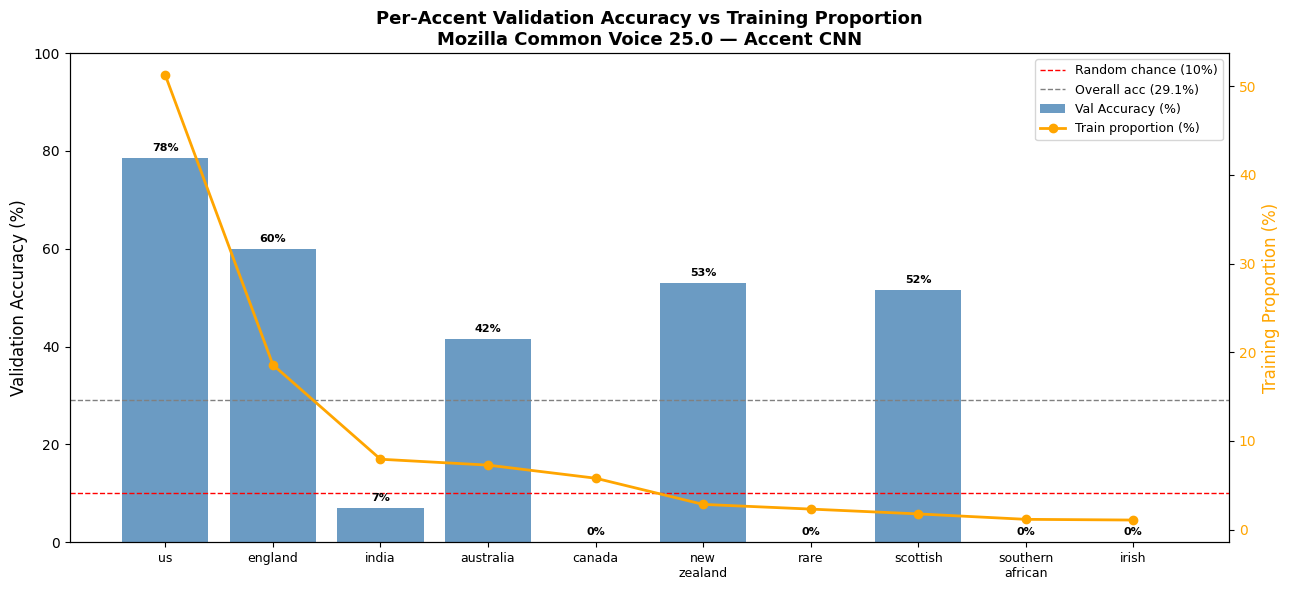


Saved to /home/hice1/mhasman3/scratch/per_accent_accuracy.png


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Reverse label map: id → accent name
ID_TO_ACCENT = {v: k for k, v in LABEL_MAP.items()}

# Load best model
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

# Collect all predictions
all_preds  = []
all_labels = []

with torch.no_grad():
    for mel, labels in tqdm(test_loader, desc="Evaluating"):
        mel    = mel.to(DEVICE)
        logits = model(mel)
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Per-accent accuracy
print("=" * 55)
print(f"{'Accent':<22} {'N':>5}  {'Correct':>7}  {'Acc':>6}  {'Train%':>7}")
print("=" * 55)

# Training proportions from our split
train_df = pd.read_csv(os.path.join(SPLITS_DIR, "train.csv"))
train_proportions = (train_df["accent"].value_counts() / len(train_df) * 100).to_dict()

results = []
for label_id in sorted(ID_TO_ACCENT.keys()):
    accent   = ID_TO_ACCENT[label_id]
    mask     = all_labels == label_id
    n        = mask.sum()
    correct  = (all_preds[mask] == label_id).sum()
    acc      = correct / n if n > 0 else 0
    train_pct = train_proportions.get(accent, 0)
    results.append({
        "accent": accent, "n": n, "correct": correct,
        "acc": acc, "train_pct": train_pct
    })
    print(f"  {accent:<20} {n:>5}  {correct:>7}  {acc:>6.1%}  {train_pct:>6.1f}%")

print("=" * 55)
print(f"  {'OVERALL':<20} {len(all_labels):>5}  {(all_preds==all_labels).sum():>7}  "
      f"{(all_preds==all_labels).mean():>6.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
results_sorted = sorted(results, key=lambda x: x["train_pct"], reverse=True)
accents   = [r["accent"].replace("_", "\n") for r in results_sorted]
accs      = [r["acc"] * 100 for r in results_sorted]
train_pcts = [r["train_pct"] for r in results_sorted]

fig, ax1 = plt.subplots(figsize=(13, 6))

x = np.arange(len(accents))
bars = ax1.bar(x, accs, color="steelblue", alpha=0.8, label="Val Accuracy (%)")
ax1.axhline(10, color="red", linestyle="--", linewidth=1, label="Random chance (10%)")
ax1.axhline((all_preds==all_labels).mean()*100, color="gray",
            linestyle="--", linewidth=1, label=f"Overall acc ({(all_preds==all_labels).mean():.1%})")
ax1.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax1.set_ylim(0, 100)
ax1.set_xticks(x)
ax1.set_xticklabels(accents, fontsize=9)

# Overlay training proportion as line
ax2 = ax1.twinx()
ax2.plot(x, train_pcts, color="orange", marker="o",
         linewidth=2, markersize=6, label="Train proportion (%)")
ax2.set_ylabel("Training Proportion (%)", fontsize=12, color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

# Add accuracy labels on bars
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{acc:.0f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)

ax1.set_title("Per-Accent Validation Accuracy vs Training Proportion\n"
              "Mozilla Common Voice 25.0 — Accent CNN", fontsize=13, fontweight="bold")

plt.tight_layout()
plot_path = "/home/hice1/"+GTID+"/scratch/per_accent_accuracy.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"\nSaved to {plot_path}")

In [18]:
# What is the model actually predicting?
from collections import Counter

pred_counts  = Counter(all_preds)
label_counts = Counter(all_labels)

print("=== What the model predicted (all test clips) ===")
for label_id in sorted(pred_counts.keys()):
    accent = ID_TO_ACCENT[label_id]
    print(f"  {accent:<22} predicted {pred_counts[label_id]:>5} times")

print("\n=== Confusion: what did it predict FOR each accent? ===")
print(f"{'Accent':<22}", end="")
for label_id in sorted(ID_TO_ACCENT.keys()):
    print(f"  {ID_TO_ACCENT[label_id][:6]:>6}", end="")
print()

for true_id in sorted(ID_TO_ACCENT.keys()):
    mask = all_labels == true_id
    preds_for_this = all_preds[mask]
    print(f"{ID_TO_ACCENT[true_id]:<22}", end="")
    for pred_id in sorted(ID_TO_ACCENT.keys()):
        count = (preds_for_this == pred_id).sum()
        print(f"  {count:>6}", end="")
    print()

=== What the model predicted (all test clips) ===
  australia              predicted   103 times
  england                predicted   502 times
  india                  predicted    20 times
  new_zealand            predicted   116 times
  scottish               predicted   110 times
  us                     predicted  1149 times

=== Confusion: what did it predict FOR each accent? ===
Accent                  austra  canada  englan   india   irish  new_ze    rare  scotti  southe      us
australia                   83       0      24       0       0       0       0       0       0      93
canada                       2       0      37       1       0       0       0       0       0     160
england                      1       0     120       1       0       1       0       0       0      77
india                        4       0      36      14       0       1       0       6       0     139
irish                        0       0      88       1       0       0       0       0       0  

In [19]:
# Where are US and Canada predictions going?
print("=== Where US clips are being predicted ===")
us_id     = LABEL_MAP["us"]
canada_id = LABEL_MAP["canada"]

us_mask  = all_labels == us_id
can_mask = all_labels == canada_id

print("\nUS true labels → predicted as:")
us_pred_counts = Counter(all_preds[us_mask])
for label_id, count in sorted(us_pred_counts.items(), key=lambda x: -x[1]):
    print(f"  {ID_TO_ACCENT[label_id]:<22} {count:>4}  ({count/200:.1%})")

print("\nCanada true labels → predicted as:")
can_pred_counts = Counter(all_preds[can_mask])
for label_id, count in sorted(can_pred_counts.items(), key=lambda x: -x[1]):
    print(f"  {ID_TO_ACCENT[label_id]:<22} {count:>4}  ({count/200:.1%})")

=== Where US clips are being predicted ===

US true labels → predicted as:
  us                      157  (78.5%)
  england                  39  (19.5%)
  australia                 2  (1.0%)
  india                     2  (1.0%)

Canada true labels → predicted as:
  us                      160  (80.0%)
  england                  37  (18.5%)
  australia                 2  (1.0%)
  india                     1  (0.5%)


In [20]:
# ── Merge Canada into US ──────────────────────────────────────────────────────
import time
from collections import Counter

SAVE_PATH3 = "/home/hice1/"+GTID+"/scratch/accent_model_unweighted.pt"

# Reload splits and merge
train_df = pd.read_csv(os.path.join(SPLITS_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(SPLITS_DIR, "test.csv"))

train_df["accent"] = train_df["accent"].replace("canada", "us")
test_df["accent"]  = test_df["accent"].replace("canada", "us")

# Label map
classes_merged   = sorted(train_df["accent"].unique())
LABEL_MAP_MERGED = {cls: i for i, cls in enumerate(classes_merged)}
ID_TO_ACCENT_MERGED = {v: k for k, v in LABEL_MAP_MERGED.items()}
NUM_CLASSES_MERGED  = len(LABEL_MAP_MERGED)

print(f"Classes ({NUM_CLASSES_MERGED}):")
for k, v in LABEL_MAP_MERGED.items():
    print(f"  {v}  {k}")

print(f"\nTrain size: {len(train_df):,}")
print(f"Test size:  {len(test_df):,}")
print("\nTrain distribution:")
print(train_df["accent"].value_counts().to_string())

# ── Dataset ───────────────────────────────────────────────────────────────────
class AccentDatasetMerged(Dataset):
    def __init__(self, df, cache_dir, label_map, mean, std):
        pairs = []
        for _, row in df.iterrows():
            npy = os.path.join(
                cache_dir,
                os.path.splitext(os.path.basename(row["full_path"]))[0] + ".npy"
            )
            if os.path.exists(npy):
                pairs.append((npy, label_map[row["accent"]]))
        self.pairs = pairs
        self.mean  = mean
        self.std   = std
        print(f"  Dataset: {len(pairs):,} clips, {len(label_map)} classes")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        npy_path, label = self.pairs[idx]
        mel = np.load(npy_path).astype(np.float32)
        mel = torch.tensor(mel).unsqueeze(0)
        mel = (mel - self.mean) / (self.std + 1e-8)
        return mel, torch.tensor(label, dtype=torch.long)

train_ds3 = AccentDatasetMerged(train_df, CACHE_DIR, LABEL_MAP_MERGED, MEAN, STD)
test_ds3  = AccentDatasetMerged(test_df,  CACHE_DIR, LABEL_MAP_MERGED, MEAN, STD)

train_loader3 = DataLoader(train_ds3, batch_size=128, shuffle=True,
                           num_workers=4, pin_memory=True, persistent_workers=True)
test_loader3  = DataLoader(test_ds3,  batch_size=128, shuffle=False,
                           num_workers=4, pin_memory=True, persistent_workers=True)

# ── Model + optimizer ─────────────────────────────────────────────────────────
model3     = AccentCNN(num_classes=NUM_CLASSES_MERGED).to(DEVICE)
optimizer3 = Adam(model3.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler3 = ReduceLROnPlateau(optimizer3, mode="max", patience=3,
                               factor=0.5, verbose=True)

criterion3 = nn.CrossEntropyLoss()

# ── Training loop ─────────────────────────────────────────────────────────────
best_acc3 = 0.0

for epoch in range(1, 21):
    model3.train()
    train_loss = train_correct = train_total = 0
    t0 = time.time()

    for mel, labels in tqdm(train_loader3, desc=f"Epoch {epoch:02d} train", leave=False):
        mel, labels = mel.to(DEVICE), labels.to(DEVICE)
        optimizer3.zero_grad()
        logits = model3(mel)
        loss   = criterion3(logits, labels)
        loss.backward()
        optimizer3.step()

        train_loss    += loss.item() * len(labels)
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_total   += len(labels)

    train_loss /= train_total
    train_acc   = train_correct / train_total

    model3.eval()
    val_loss = val_correct = val_total = 0

    with torch.no_grad():
        for mel, labels in tqdm(test_loader3, desc=f"Epoch {epoch:02d} val  ", leave=False):
            mel, labels = mel.to(DEVICE), labels.to(DEVICE)
            logits      = model3(mel)
            loss        = criterion3(logits, labels)

            val_loss   += loss.item() * len(labels)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += len(labels)

    val_loss /= val_total
    val_acc   = val_correct / val_total
    scheduler3.step(val_acc)

    if val_acc > best_acc3:
        best_acc3 = val_acc
        torch.save(model3.state_dict(), SAVE_PATH3)
        saved = "✓ saved"
    else:
        saved = ""

    print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f} | "
          f"{time.time()-t0:.1f}s {saved}")

print(f"\nBest val accuracy: {best_acc3:.3f}")

Classes (9):
  0  australia
  1  england
  2  india
  3  irish
  4  new_zealand
  5  rare
  6  scottish
  7  southern_african
  8  us

Train size: 25,000
Test size:  2,000

Train distribution:
us                  14253
england              4645
india                1985
australia            1819
new_zealand           712
rare                  580
scottish              444
southern_african      291
irish                 271
  Dataset: 25,000 clips, 9 classes
  Dataset: 2,000 clips, 9 classes


Epoch 01 | train loss 1.4557 acc 0.563 | val loss 2.7037 acc 0.200 | 4.1s ✓ saved


Epoch 02 | train loss 1.3924 acc 0.570 | val loss 2.7771 acc 0.200 | 3.7s 


Epoch 03 | train loss 1.3745 acc 0.571 | val loss 2.5710 acc 0.201 | 3.7s ✓ saved


Epoch 04 | train loss 1.3521 acc 0.575 | val loss 2.6934 acc 0.248 | 3.7s ✓ saved


...

Epoch 16 | train loss 1.1475 acc 0.635 | val loss 2.2268 acc 0.349 | 3.7s ✓ saved


Epoch 17 | train loss 1.1358 acc 0.639 | val loss 2.2597 acc 0.344 | 3.7s 


Epoch 18 | train loss 1.1186 acc 0.643 | val loss 2.1905 acc 0.359 | 3.7s ✓ saved


Epoch 19 | train loss 1.1110 acc 0.646 | val loss 2.2127 acc 0.345 | 3.7s 


Epoch 20 | train loss 1.1017 acc 0.650 | val loss 2.2059 acc 0.349 | 3.9s 

Best val accuracy: 0.359


In [21]:
# ── Per-accent evaluation ─────────────────────────────────────────────────────
model3.load_state_dict(torch.load(SAVE_PATH3, map_location=DEVICE))
model3.eval()

all_preds3  = []
all_labels3 = []

with torch.no_grad():
    for mel, labels in tqdm(test_loader3, desc="Evaluating"):
        logits = model3(mel.to(DEVICE))
        all_preds3.extend(logits.argmax(1).cpu().numpy())
        all_labels3.extend(labels.numpy())

all_preds3  = np.array(all_preds3)
all_labels3 = np.array(all_labels3)

print("\n=== Prediction distribution ===")
pred_counts3 = Counter(all_preds3)
for label_id in sorted(ID_TO_ACCENT_MERGED.keys()):
    print(f"  {ID_TO_ACCENT_MERGED[label_id]:<22} predicted "
          f"{pred_counts3.get(label_id, 0):>5} times")

train_proportions3 = (train_df["accent"].value_counts() /
                      train_df["accent"].value_counts().sum() * 100).to_dict()

print("\n" + "=" * 58)
print(f"{'Accent':<22} {'N':>5}  {'Correct':>7}  {'Acc':>6}  {'Train%':>7}")
print("=" * 58)

results3 = []
for label_id in sorted(ID_TO_ACCENT_MERGED.keys()):
    accent    = ID_TO_ACCENT_MERGED[label_id]
    mask      = all_labels3 == label_id
    n         = mask.sum()
    correct   = (all_preds3[mask] == label_id).sum()
    acc       = correct / n if n > 0 else 0
    train_pct = train_proportions3.get(accent, 0)

    results3.append({
        "accent": accent,
        "n": n,
        "correct": correct,
        "acc": acc,
        "train_pct": train_pct
    })

    print(f"  {accent:<22} {n:>5}  {correct:>7}  {acc:>6.1%}  {train_pct:>6.1f}%")

print("=" * 58)
overall_acc3 = (all_preds3 == all_labels3).mean()
print(f"  {'OVERALL':<22} {len(all_labels3):>5}  "
      f"{(all_preds3==all_labels3).sum():>7}  {overall_acc3:>6.1%}")

Evaluating: 100%|██████████| 16/16 [00:00<00:00, 72.24it/s]


=== Prediction distribution ===
  australia              predicted    80 times
  england                predicted   249 times
  india                  predicted     0 times
  irish                  predicted     0 times
  new_zealand            predicted   102 times
  rare                   predicted     0 times
  scottish               predicted   101 times
  southern_african       predicted     0 times
  us                     predicted  1468 times

Accent                     N  Correct     Acc   Train%
  australia                200       72   36.0%     7.3%
  england                  200       83   41.5%    18.6%
  india                    200        0    0.0%     7.9%
  irish                    200        0    0.0%     1.1%
  new_zealand              200       94   47.0%     2.8%
  rare                     200        0    0.0%     2.3%
  scottish                 200      101   50.5%     1.8%
  southern_african         200        0    0.0%     1.2%
  us                       400  

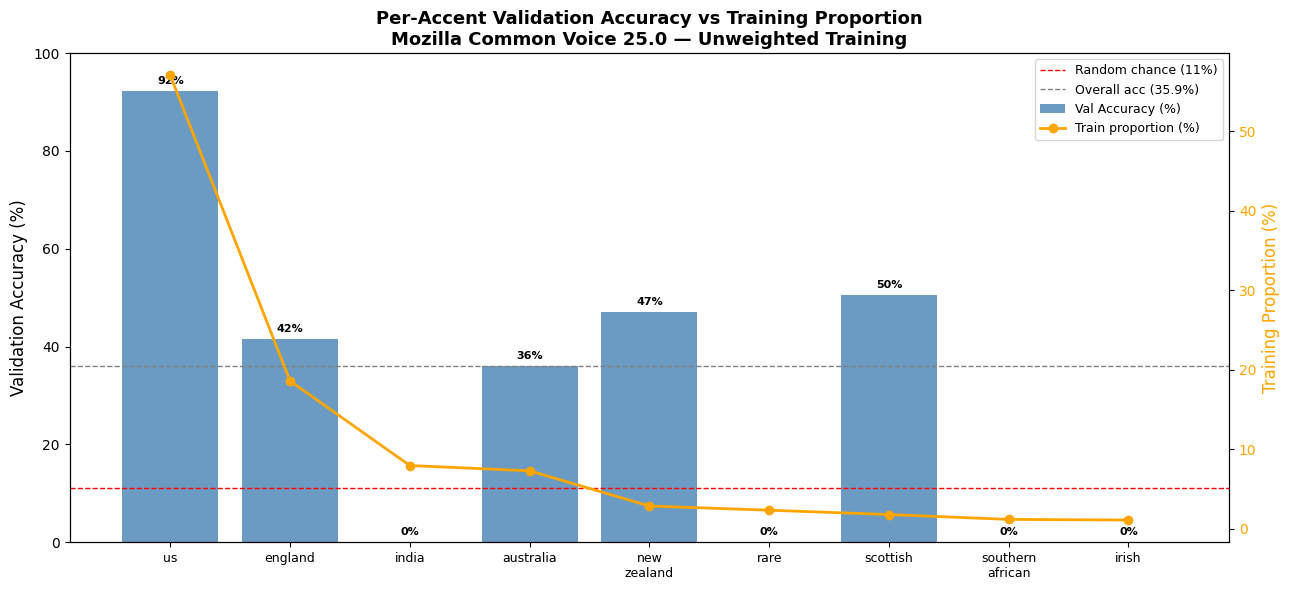


Saved to /home/hice1/mhasman3/scratch/per_accent_accuracy_unweighted.png


In [22]:
# ── Plot ──────────────────────────────────────────────────────────────────────
results_sorted3 = sorted(results3, key=lambda x: x["train_pct"], reverse=True)

accents3    = [r["accent"].replace("_", "\n") for r in results_sorted3]
accs3       = [r["acc"] * 100 for r in results_sorted3]
train_pcts3 = [r["train_pct"] for r in results_sorted3]

fig, ax1 = plt.subplots(figsize=(13, 6))
x = np.arange(len(accents3))

bars = ax1.bar(x, accs3, color="steelblue", alpha=0.8,
               label="Val Accuracy (%)")

ax1.axhline(100/NUM_CLASSES_MERGED, color="red", linestyle="--",
            linewidth=1, label=f"Random chance ({100/NUM_CLASSES_MERGED:.0f}%)")

ax1.axhline(overall_acc3 * 100, color="gray", linestyle="--",
            linewidth=1, label=f"Overall acc ({overall_acc3:.1%})")

ax1.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax1.set_ylim(0, 100)
ax1.set_xticks(x)
ax1.set_xticklabels(accents3, fontsize=9)

# Secondary axis: training proportion
ax2 = ax1.twinx()
ax2.plot(x, train_pcts3, color="orange", marker="o",
         linewidth=2, markersize=6, label="Train proportion (%)")
ax2.set_ylabel("Training Proportion (%)", fontsize=12, color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

# Labels on bars
for bar, acc in zip(bars, accs3):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f"{acc:.0f}%",
             ha="center", va="bottom",
             fontsize=8, fontweight="bold")

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper right", fontsize=9)

ax1.set_title(
    "Per-Accent Validation Accuracy vs Training Proportion\n"
    "Mozilla Common Voice 25.0 — Unweighted Training",
    fontsize=13, fontweight="bold"
)

plt.tight_layout()

plot_path3 = "/home/hice1/"+GTID+"/scratch/per_accent_accuracy_unweighted.png"
plt.savefig(plot_path3, dpi=150)
plt.show()

print(f"\nSaved to {plot_path3}")

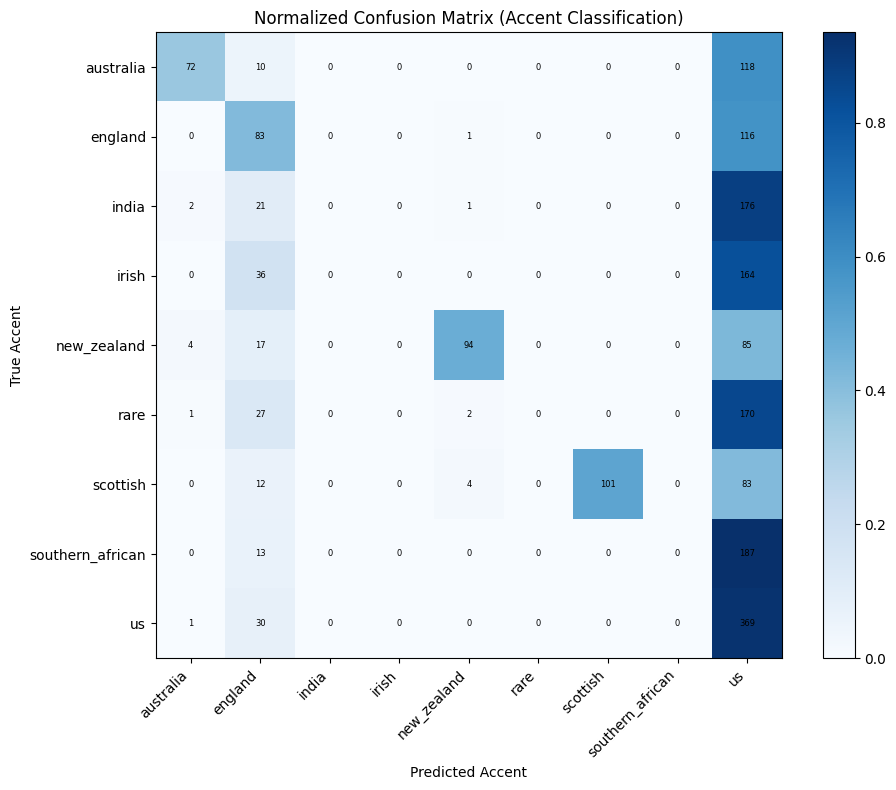

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ── Build confusion matrix ────────────────────────────────────────────────
labels = np.array(all_labels3)
preds  = np.array(all_preds3)

num_classes = len(ID_TO_ACCENT_MERGED)
cm = np.zeros((num_classes, num_classes), dtype=int)

for t, p in zip(labels, preds):
    cm[int(t), int(p)] += 1

# ── Normalize (optional but VERY useful) ───────────────────────────────────
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-8)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cm_norm, cmap="Blues")

# Labels
class_names = [ID_TO_ACCENT_MERGED[i] for i in range(num_classes)]

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted Accent")
ax.set_ylabel("True Accent")
ax.set_title("Normalized Confusion Matrix (Accent Classification)")

# Annotate (counts + optional normalized value)
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(
            j, i,
            f"{cm[i, j]}",
            ha="center",
            va="center",
            fontsize=6,
            color="black"
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [24]:
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-8)

print("\nNormalized Confusion Matrix (row-wise):\n")

header = "True \\ Pred".ljust(18) + " ".join([f"{c[:10]:>10}" for c in class_names])
print(header)
print("-" * len(header))

for i, row_name in enumerate(class_names):
    row_str = f"{row_name[:16]:<16} "
    for j in range(num_classes):
        row_str += f"{cm_norm[i, j]:10.2f}"
    print(row_str)


Normalized Confusion Matrix (row-wise):

True \ Pred        australia    england      india      irish new_zealan       rare   scottish southern_a         us
--------------------------------------------------------------------------------------------------------------------
australia              0.36      0.05      0.00      0.00      0.00      0.00      0.00      0.00      0.59
england                0.00      0.41      0.00      0.00      0.00      0.00      0.00      0.00      0.58
india                  0.01      0.10      0.00      0.00      0.00      0.00      0.00      0.00      0.88
irish                  0.00      0.18      0.00      0.00      0.00      0.00      0.00      0.00      0.82
new_zealand            0.02      0.08      0.00      0.00      0.47      0.00      0.00      0.00      0.42
rare                   0.00      0.13      0.00      0.00      0.01      0.00      0.00      0.00      0.85
scottish               0.00      0.06      0.00      0.00      0.02      0.0

In [25]:
from sklearn.metrics import f1_score, classification_report

# ── F1 Scores ────────────────────────────────────────────────────────────────
f1_per_class = f1_score(all_labels3, all_preds3, average=None)
f1_macro     = f1_score(all_labels3, all_preds3, average="macro")
f1_weighted  = f1_score(all_labels3, all_preds3, average="weighted")

print("=" * 45)
print(f"{'Accent':<22} {'F1 Score':>10}")
print("=" * 45)
for label_id in sorted(ID_TO_ACCENT_MERGED.keys()):
    accent = ID_TO_ACCENT_MERGED[label_id]
    print(f"  {accent:<22} {f1_per_class[label_id]:>10.4f}")
print("=" * 45)
print(f"  {'Macro F1':<22} {f1_macro:>10.4f}")
print(f"  {'Weighted F1':<22} {f1_weighted:>10.4f}")
print("=" * 45)

print("\n\n── Full Classification Report ───────────────────────────────────────────────")
print(classification_report(
    all_labels3,
    all_preds3,
    target_names=[ID_TO_ACCENT_MERGED[i] for i in sorted(ID_TO_ACCENT_MERGED.keys())]
))

Accent                   F1 Score
  australia                  0.5143
  england                    0.3697
  india                      0.0000
  irish                      0.0000
  new_zealand                0.6225
  rare                       0.0000
  scottish                   0.6711
  southern_african           0.0000
  us                         0.3951
  Macro F1                   0.2859
  Weighted F1                0.2968


── Full Classification Report ───────────────────────────────────────────────
                  precision    recall  f1-score   support

       australia       0.90      0.36      0.51       200
         england       0.33      0.41      0.37       200
           india       0.00      0.00      0.00       200
           irish       0.00      0.00      0.00       200
     new_zealand       0.92      0.47      0.62       200
            rare       0.00      0.00      0.00       200
        scottish       1.00      0.51      0.67       200
southern_african       0.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
